In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

# Part A — Discrete Chaotic Systems

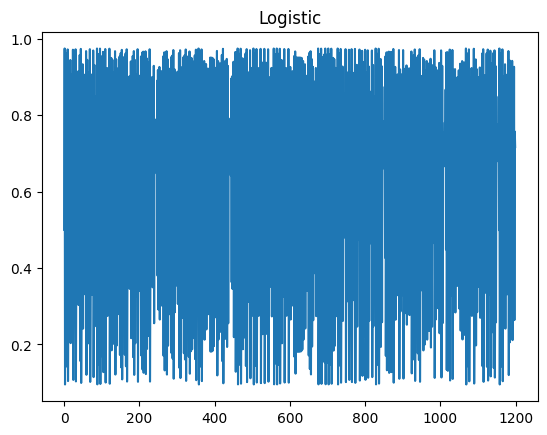

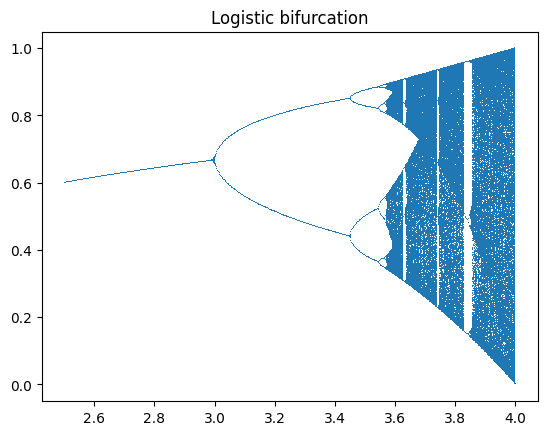

In [10]:
# Logistic Map
def logistic(r,x0=0.5,n=1200):
    x=np.zeros(n);x[0]=x0
    for i in range(n-1): x[i+1]=r*x[i]*(1-x[i])
    return x

x=logistic(3.9)

# Logistic Time Series
plt.plot(x);plt.title("Logistic");plt.show()

R=[];X=[]
for r in np.linspace(2.5,4,600):
    y=logistic(r)[300:]
    R.extend([r]*len(y));X.extend(y)
    
# Logistic Bifurcation Diagram
plt.plot(R,X,',');plt.title("Logistic bifurcation");plt.show()

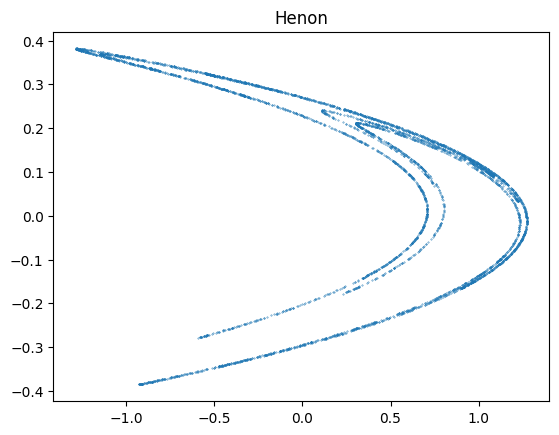

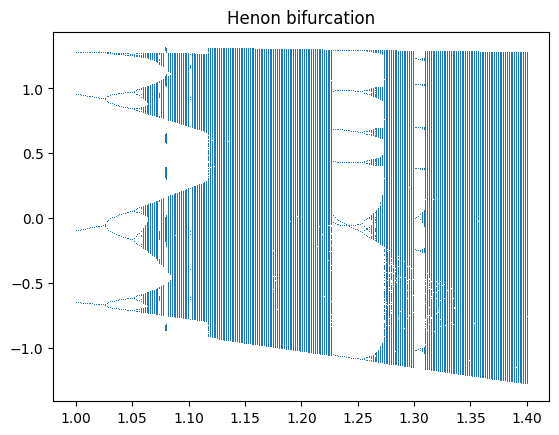

In [11]:
# Henon Map
def henon(a=1.4,b=0.3,n=5000):
    x=np.zeros(n);y=np.zeros(n)
    for i in range(n-1):
        x[i+1]=1-a*x[i]**2+y[i]
        y[i+1]=b*x[i]
    return x,y

x,y=henon()

# Henon Attractor
plt.scatter(x[500:],y[500:],s=.1);plt.title("Henon");plt.show()

R=[];X=[]
for a in np.linspace(1,1.4,250):
    x,y=henon(a=a)
    R.extend([a]*len(x[500:]));X.extend(x[500:])

# Henon Bifurcation Diagram    
plt.plot(R,X,',');plt.title("Henon bifurcation");plt.show()

# Part B — Continuous Chaotic Systems

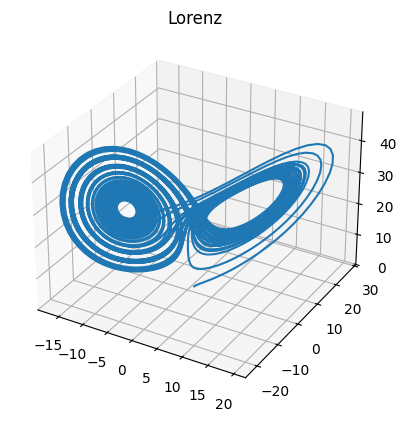

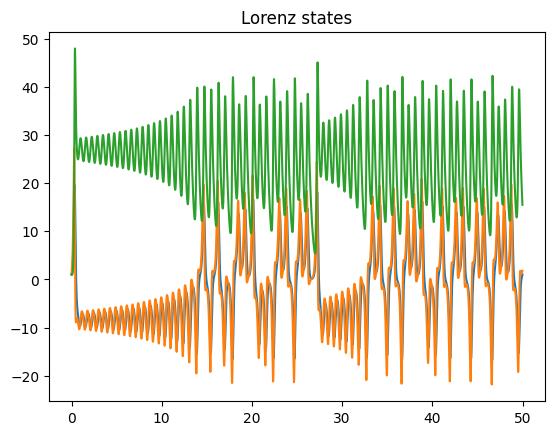

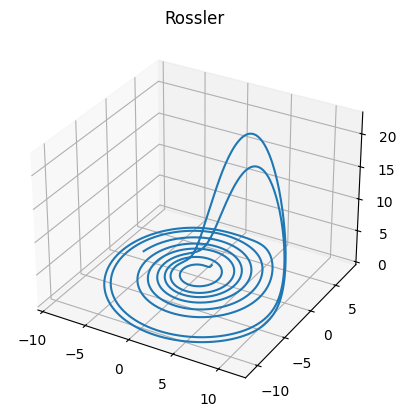

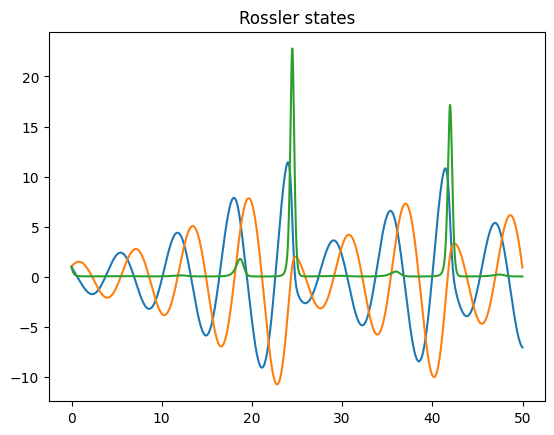

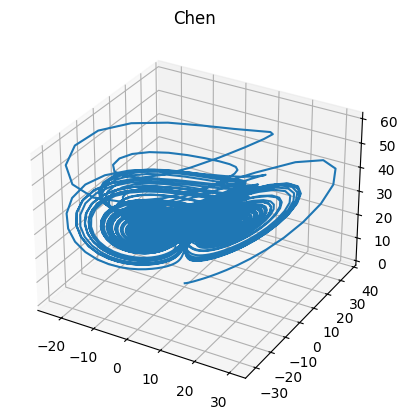

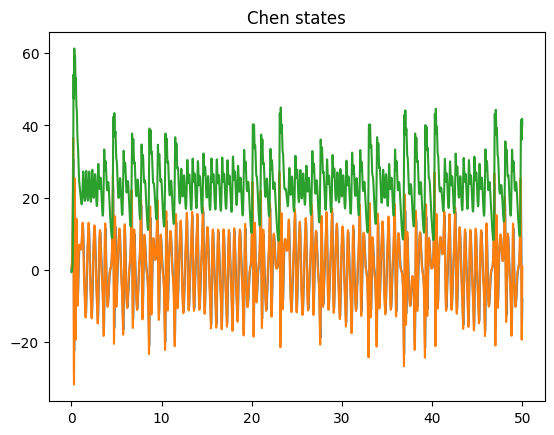

In [12]:
# Chaotic systems
def sim(fun,y0,t,p):
 sol=solve_ivp(lambda t,y:fun(t,y,*p),[0,t[-1]],y0,t_eval=t)
 return sol.y

# Lorenz, Rossler, Chen
def lor(t,s,sig,rho,b):
 x,y,z=s;return[sig*(y-x),x*(rho-z)-y,x*y-b*z]
 
def ros(t,s,a,b,c):
 x,y,z=s;return[-y-z,x+a*y,b+z*(x-c)]
 
def chen(t,s,a,b,c):
 x,y,z=s;return[a*(y-x),(c-a)*x-x*z+c*y,x*y-b*z]
 
t=np.arange(0,50,.01)
for name,f,y0,p in [
("Lorenz",lor,[1,1,1],[10,28,8/3]),
("Rossler",ros,[1,1,1],[0.2,0.2,5.7]),
("Chen",chen,[-.1,.5,-.6],[35,3,28])]:
 Y=sim(f,y0,t,p)
 fig=plt.figure();ax=fig.add_subplot(111,projection="3d")
 
 # 3D Phase Portrait
 ax.plot(Y[0],Y[1],Y[2]);ax.set_title(name);plt.show()
 
 # Time Series
 plt.plot(t,Y.T);plt.title(name+" states");plt.show()

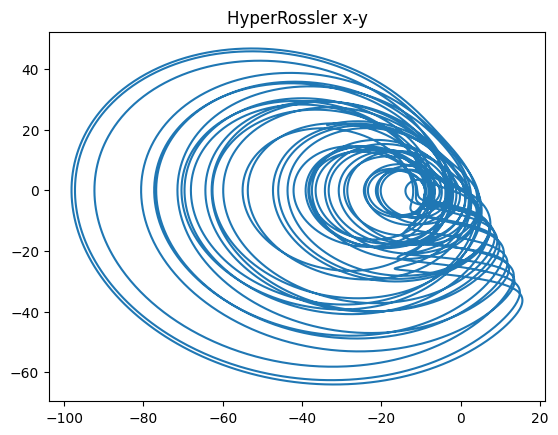

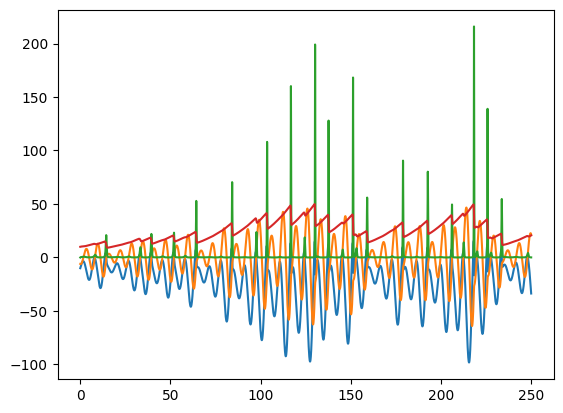

In [13]:
# HyperRossler
def hros(t,s,a,b,c,d):
 x,y,z,w=s
 return[-y-z,x+a*y+w,b+x*z,-c*z+d*w]
t=np.arange(0,250,.01)
Y=solve_ivp(lambda t,y:hros(t,y,.25,3,.5,.05),[0,t[-1]],[-10,-6,0,10],t_eval=t).y
plt.plot(Y[0],Y[1]);plt.title("HyperRossler x-y");plt.show()
plt.plot(t,Y.T);plt.show()

# Part C — Sensitivity Analysis

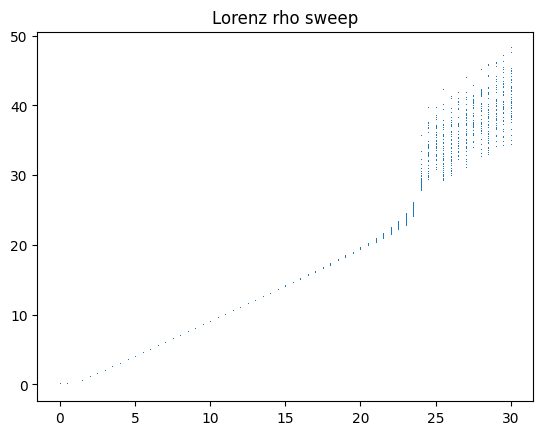

In [14]:
# Parameter sweep of the Lorenz system
rhos=np.arange(0,30.1,.5);R=[];M=[]

for rho in rhos:
 y=sim(lor,[1,1,1],np.arange(0,50,.01),[10,rho,8/3])[2]
 z=y[2000:]
 idx=(z[1:-1]>z[:-2])&(z[1:-1]>z[2:])
 m=z[1:-1][idx]
 R.extend([rho]*len(m));M.extend(m)
 
plt.plot(R,M,',');plt.title("Lorenz rho sweep");plt.show()

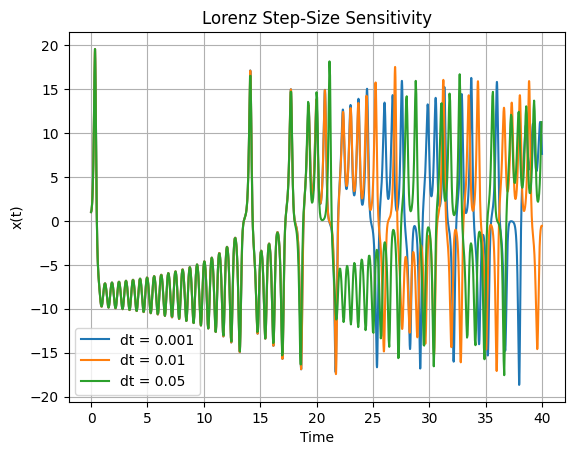

In [ ]:
# Step-size sensitivity

#
dts = [0.001, 0.01, 0.05]
solutions = {}

for dt in dts:
    t = np.arange(0, 40, dt)

    sol = solve_ivp(
        lambda t, y: lor(t, y, 10, 28, 8/3),
        [0, 40],
        [1, 1, 1],
        t_eval=t,
        max_step=dt,
        rtol=1e-6,
        atol=1e-9
    )

    solutions[dt] = sol

    plt.plot(sol.t, sol.y[0], label=f"dt = {dt}")

plt.title("Lorenz Step-Size Sensitivity")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

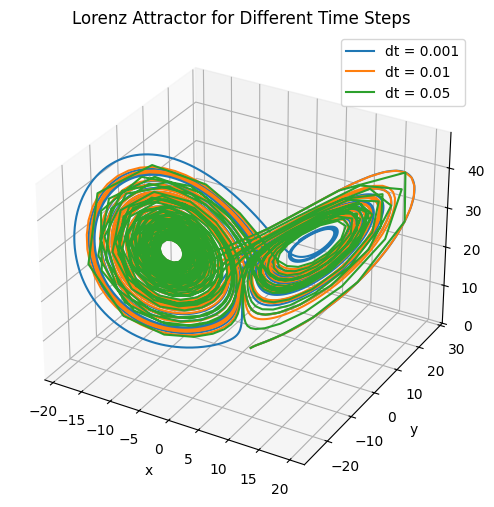

In [ ]:
# 3-D phase-space trajectories

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for dt in dts:
    sol = solutions[dt]

    ax.plot(
        sol.y[0],
        sol.y[1],
        sol.y[2],
        label=f"dt = {dt}"
    )

ax.set_title("Lorenz Attractor for Different Time Steps")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

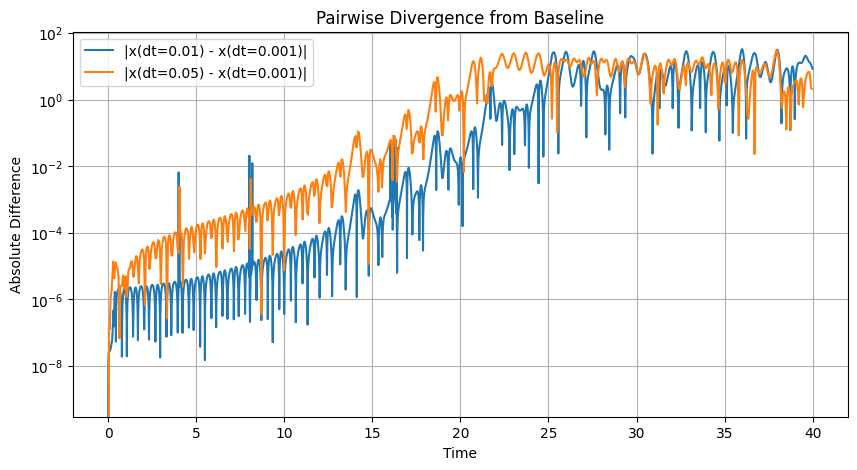

In [ ]:
# Pairwise divergence |x_dt(t) − x_baseline(t)| vs. t
baseline = solutions[0.001]

plt.figure(figsize=(10,5))

for dt in [0.01, 0.05]:

    sol = solutions[dt]

    idx = (sol.t / 0.001).astype(int)

    x_ref = baseline.y[0, idx]

    divergence = np.abs(sol.y[0] - x_ref)

    plt.semilogy(
        sol.t,
        divergence,
        label=f"|x(dt={dt}) - x(dt=0.001)|"
    )

plt.title("Pairwise Divergence from Baseline")
plt.xlabel("Time")
plt.ylabel("Absolute Difference")
plt.legend()
plt.grid(True)

plt.show()